In [1]:
import numpy as np
import pandas as pd
from evabox import utils, ephys, plotting, preprocessing
import glob, os
from pathlib import Path

In [2]:
animal = "eb08"
date = "20260425"
params = utils.params_dict(animal, date)
params

{'animal': 'eb08',
 'date': '20260425',
 'merged': True,
 'subsession': None,
 'fps': 120,
 'fs': 30000,
 'ttl_type': 'continuous'}

In [3]:
paths = utils.build_paths(params['animal'], params['date'])
paths

{'data_raw_ephys': PosixPath('/storage3/eva/data/raw/eb08/eb08_20260425/ephys'),
 'data_raw_motive': PosixPath('/storage3/eva/data/raw/eb08/eb08_20260425/motive'),
 'data_processed_ks': PosixPath('/storage3/eva/data/processed/eb08/eb08_20260425/ephys/eb08_20260425_merged/kilosort4'),
 'data_processed_rec': PosixPath('/storage3/eva/data/processed/eb08/eb08_20260425/ephys/eb08_20260425_merged/recording/raw_merged'),
 'data_processed_ttl': PosixPath('/storage3/eva/data/processed/eb08/eb08_20260425/ephys/eb08_20260425_merged/recording/ttl'),
 'data_processed_unitmatch': PosixPath('/storage3/eva/data/processed/eb08/unitmatch'),
 'data_processed_motive': PosixPath('/storage3/eva/data/processed/eb08/eb08_20260425/motive'),
 'results_animal': PosixPath('/storage3/eva/results/eb08'),
 'results_session': PosixPath('/storage3/eva/results/eb08/eb08_20260425')}

## Here i m comparing old and new motive

In [5]:
ddf=[]
files_csv = [paths['data_raw_motive']/ 'eb08_20260425_1.csv',
             paths['data_raw_motive']/ 'eb08_20260425_2.csv',
             Path('/storage3/eva/data/raw/eb05/eb05_20251117/motive/eb05_20251117_2.csv'),
             Path('/storage3/eva/data/raw/eb02/eb02_20250717/motive/eb02_20250717_2.csv')]

for file_path in files_csv:
    ddf.append(preprocessing.load_motive_csv(file_path))

In [6]:
# for table in ddf:
#     display(table.head(10))

In [7]:
meta_list = []
for table in ddf:
    meta_list.append(preprocessing.get_meta(table))

for meta_dict in meta_list:
    display(meta_dict)

{'Format Version': '1.25',
 'Take Name': 'eb08_20260425_1',
 'Take Notes': '',
 'Capture Frame Rate': '120.000000',
 'Export Frame Rate': '120.000000',
 'Capture Start Time': '2026-04-25 11.21.21.698 AM',
 'Capture Start Frame': '5899',
 'Total Frames in Take': '295423',
 'Total Exported Frames': '295423',
 'Rotation Type': 'Quaternion',
 'Length Units': 'Meters',
 'Coordinate Space': 'Global',
 'Duration_s': 2461.85,
 'Duration_m': 41.030833333333334}

{'Format Version': '1.25',
 'Take Name': 'eb08_20260425_2',
 'Take Notes': '',
 'Capture Frame Rate': '120.000000',
 'Export Frame Rate': '120.000000',
 'Capture Start Time': '2026-04-25 12.11.04.775 PM',
 'Capture Start Frame': '363866',
 'Total Frames in Take': '268684',
 'Total Exported Frames': '268684',
 'Rotation Type': 'Quaternion',
 'Length Units': 'Meters',
 'Coordinate Space': 'Global',
 'Duration_s': 2239.025,
 'Duration_m': 37.317083333333336}

{'Format Version': '1.21',
 'Take Name': 'eb05_20251117_2',
 'Capture Frame Rate': '120.000046',
 'Export Frame Rate': '120.000046',
 'Capture Start Time': '2025-11-17 11.34.38.180 AM',
 'Total Frames in Take': '217340',
 'Total Exported Frames': '217340',
 'Rotation Type': 'Quaternion',
 'Length Units': 'Meters',
 'Coordinate Space': 'Global',
 'Duration_s': 1811.157642,
 'Duration_m': 30.1859607}

{'Format Version': '1.21',
 'Take Name': 'eb02_20250717_2',
 'Capture Frame Rate': '120.000046',
 'Export Frame Rate': '120.000046',
 'Capture Start Time': '2025-07-17 11.01.52.708 AM',
 'Total Frames in Take': '213823',
 'Total Exported Frames': '213823',
 'Rotation Type': 'Quaternion',
 'Length Units': 'Meters',
 'Coordinate Space': 'Global',
 'Duration_s': 1781.84932,
 'Duration_m': 29.69748866666667}

## Here i m testing preprocessing.py module on 1 session from new motive

In [4]:
# %% csv-->pandas for each csv in the loop 
ddf=[]
files_csv = glob.glob(os.path.join(paths['data_raw_motive'], '*.csv'))

for file_path in files_csv:
    ddf.append(preprocessing.load_motive_csv(file_path))

# %% parse motive meta
meta_list = [] # list with dicts that store meta for every subsession
for table in ddf:
    meta_list.append(preprocessing.get_meta(table))
# %%
parsed_dicts = []
for table in ddf:
    parsed_dicts.append(preprocessing.parse_motive(table))

├── time_s: array (295423,) float64
├── frames: array (295423,) int64
├── rigid_body
│   └── rat
│       ├── rotation
│       │   ├── x: array (295423,) float64
│       │   ├── y: array (295423,) float64
│       │   ├── z: array (295423,) float64
│       │   └── w: array (295423,) float64
│       └── position
│           ├── x: array (295423,) float64
│           ├── y: array (295423,) float64
│           └── z: array (295423,) float64
└── markers
    ├── rat_1
    │   ├── position
    │   │   ├── x: array (295423,) float64
    │   │   ├── y: array (295423,) float64
    │   │   └── z: array (295423,) float64
    │   └── parent: 'rat'
    ├── rat_2
    │   ├── position
    │   │   ├── x: array (295423,) float64
    │   │   ├── y: array (295423,) float64
    │   │   └── z: array (295423,) float64
    │   └── parent: 'rat'
    ├── rat_3
    │   ├── position
    │   │   ├── x: array (295423,) float64
    │   │   ├── y: array (295423,) float64
    │   │   └── z: array (295423,) float64
    

## hdf5

In [5]:
# --- derive the session id from the takes; assert all CSVs are one session ---
subsession_ids = [m["Take Name"] for m in meta_list]
sessions = {sid.rpartition("_")[0] for sid in subsession_ids}
assert len(sessions) == 1, f"CSVs span multiple sessions: {sessions}"
session = sessions.pop()                 # e.g. 'eb08_20260425'
animal  = session.split("_")[0]          # e.g. 'eb08'

# --- load the two google-sheet tabs (your existing utils.load_tab) ---
sessions_df    = utils.load_tab(animal, "Sessions")
subsessions_df = utils.load_tab(animal, "SubSessions")

# --- build the HDF5 file for this session ---
out_path = Path(paths["data_processed_motive"]) / f"{session}.h5"
out_path.parent.mkdir(parents=True, exist_ok=True)

problems = preprocessing.write_session_file(
    out_path, session,
    parsed_dicts, meta_list,        # the two parallel lists you just built
    sessions_df, subsessions_df,
    mode="w",                       # 'w' = fresh build; 'a' = add subsessions to existing file
)

[write_session_file] all sheet attributes written.


In [ ]:
#check for NaNs, interpolate
# one example

In [4]:
import h5py

In [15]:
subsession = f"{animal}_{date}_1"
path = Path(paths["data_processed_motive"]) / f"{animal}_{date}.h5"

with h5py.File(path, "r") as f:                     # "r": read-only, fails loud on bad path
    base = f[f"{subsession}/raw/rigid_bodies/rat"]   # grab the group once...
    rat_pos_x = base["pos_x"][:]                     # ...then index channels off it
    rat_pos_y = base["pos_y"][:]
    rat_pos_z = base["pos_z"][:]
    rat_rot_x = base["rot_x"][:]                     # ...then index channels off it
    rat_rot_y = base["rot_y"][:]
    rat_rot_z = base["rot_z"][:]
    rat_rot_w = base["rot_w"][:]

display(rat_pos_x)

array([0.078907, 0.078878, 0.078855, ..., 0.246139, 0.246145, 0.246135],
      shape=(295423,))

In [16]:
rat_pos_x_nan = np.isnan(rat_pos_x).mean() * 100
rat_pos_y_nan = np.isnan(rat_pos_y).mean() * 100
rat_pos_z_nan = np.isnan(rat_pos_z).mean() * 100
rat_rot_x_nan = np.isnan(rat_rot_x).mean() * 100
rat_rot_y_nan = np.isnan(rat_rot_y).mean() * 100
rat_rot_z_nan = np.isnan(rat_rot_z).mean() * 100
rat_rot_w_nan = np.isnan(rat_rot_w).mean() * 100
print(rat_pos_x_nan, rat_pos_y_nan, rat_pos_z_nan, rat_rot_x_nan,rat_rot_y_nan, rat_rot_z_nan, rat_rot_w_nan)

0.0 0.0 0.0 0.0 0.0 0.0 0.0


In [14]:
print(np.isnan(rat_pos_x).any(),
      np.isnan(rat_pos_y).any(),
      np.isnan(rat_pos_z).any())

False False False


In [5]:
out_path = Path(paths["data_processed_motive"]) / f"{animal}_{date}.h5"

preprocessing.process_session_file(out_path, max_gap_frames=12)

PosixPath('/storage3/eva/data/processed/eb08/eb08_20260425/motive/eb08_20260425.h5')

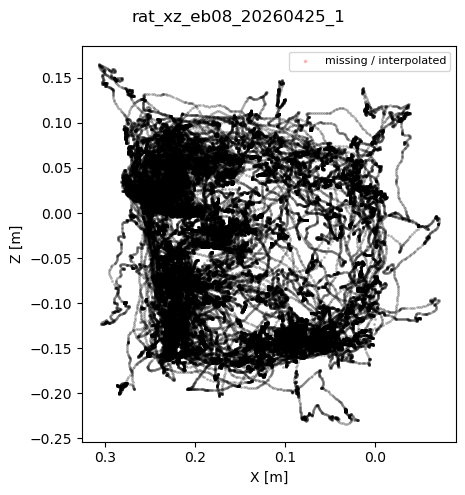

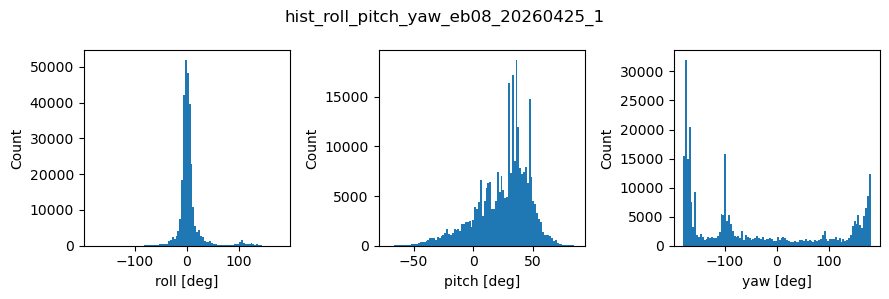

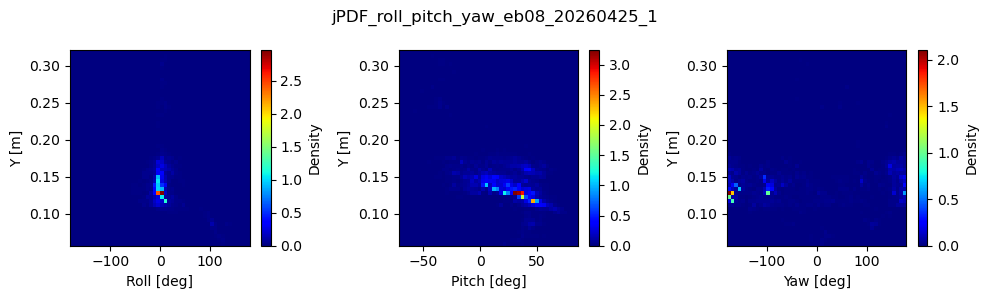

/storage3/eva/code/evabox/src/evabox/preprocessing.py:1351: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.tight_layout()
/storage3/eva/code/evabox/src/evabox/preprocessing.py:1355: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.savefig(save_dir / f"{filename}.png", dpi=300, bbox_inches="tight")
/storage3/eva/apps/anaconda3/envs/remapping/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


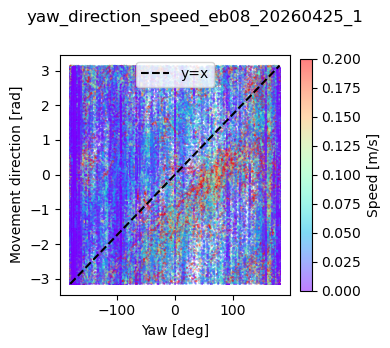

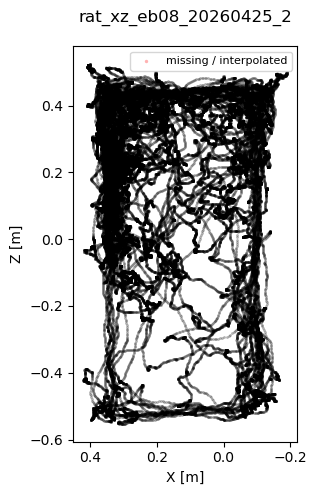

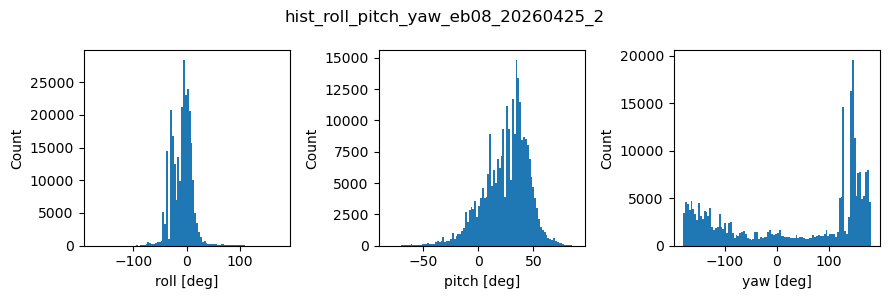

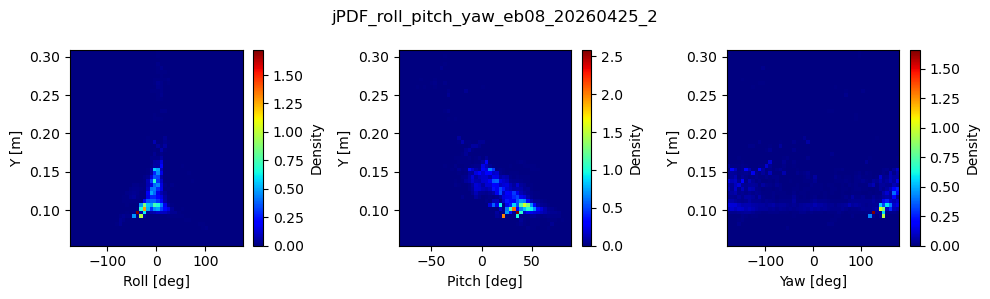

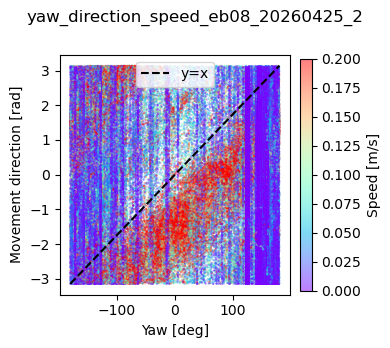

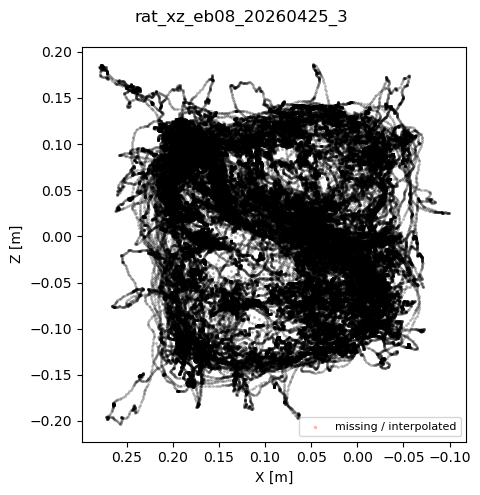

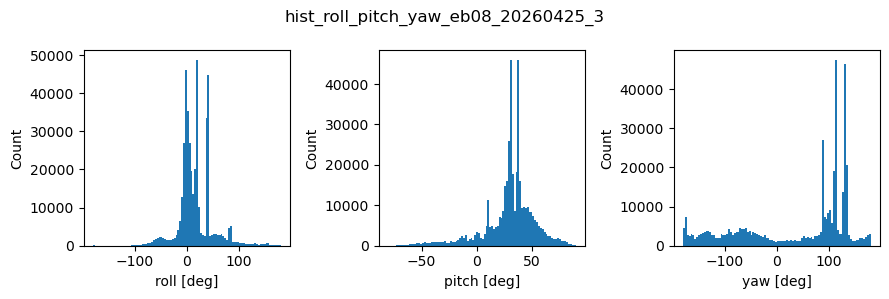

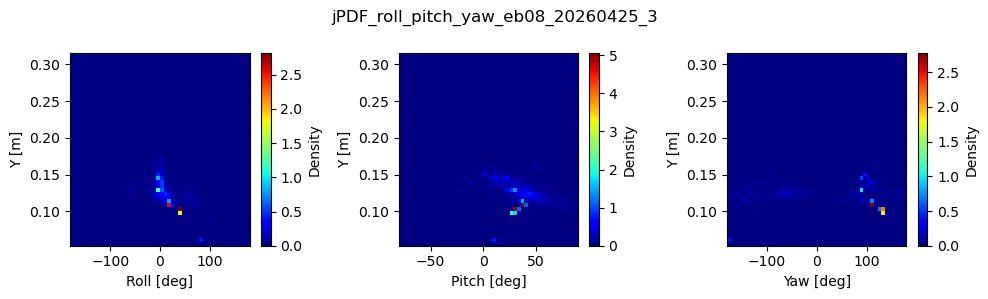

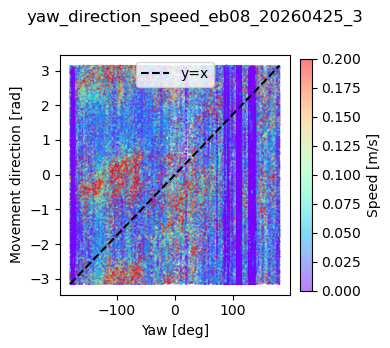

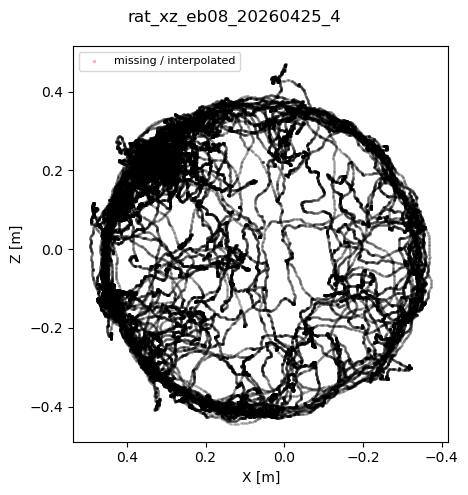

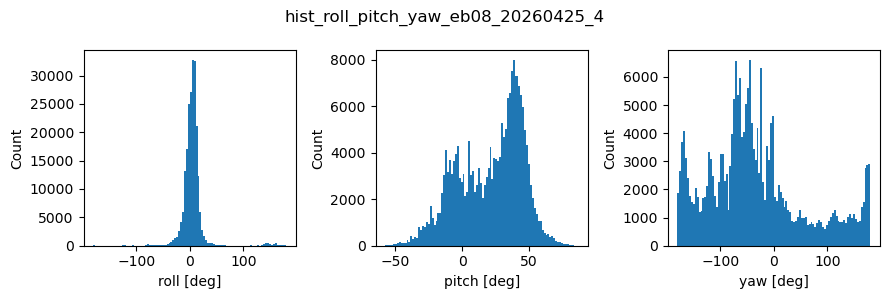

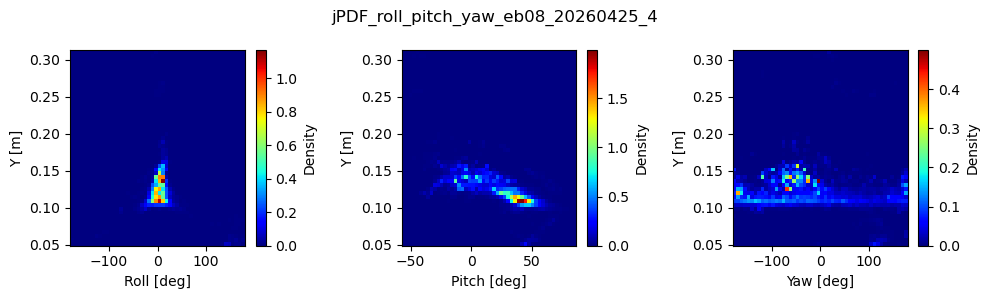

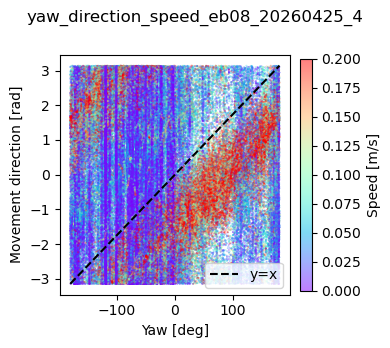

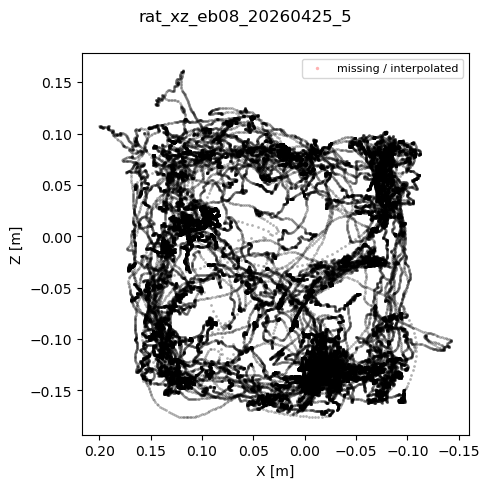

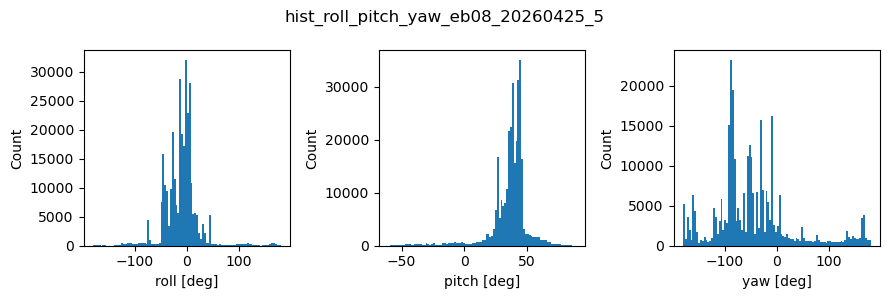

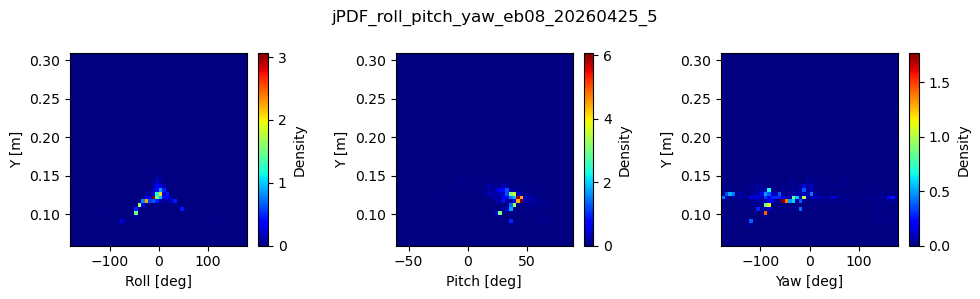

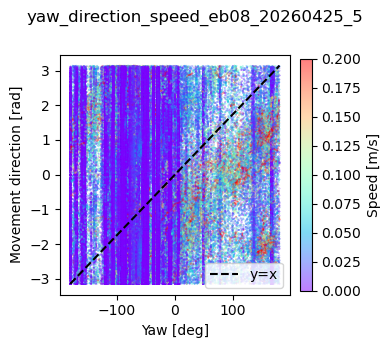

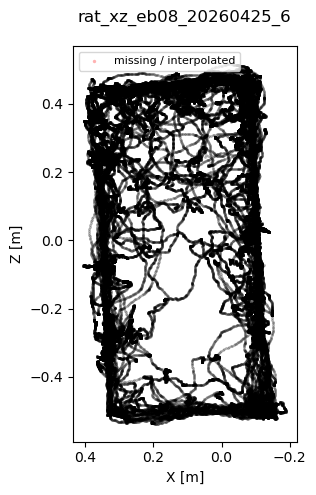

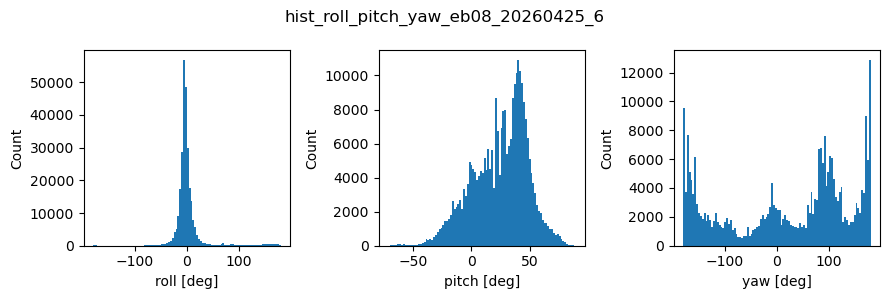

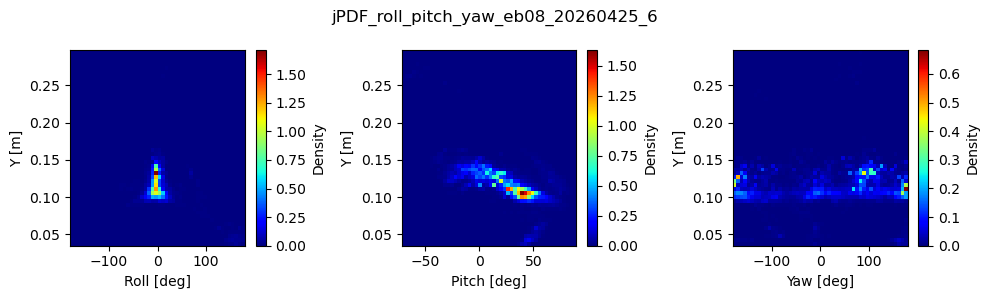

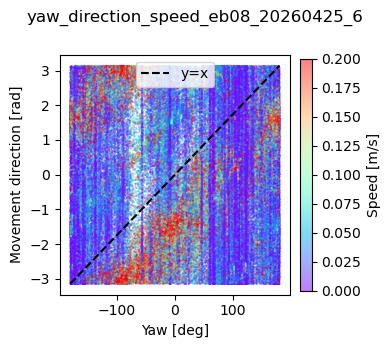

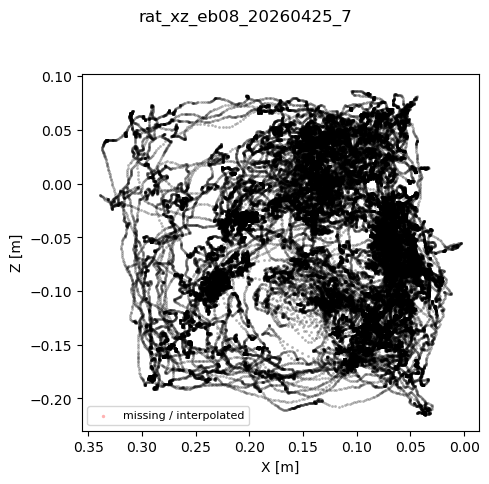

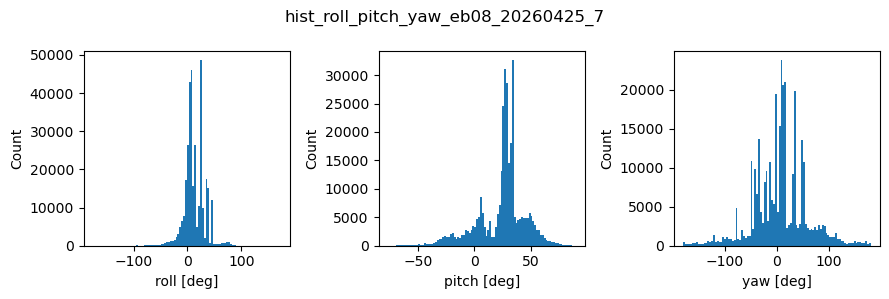

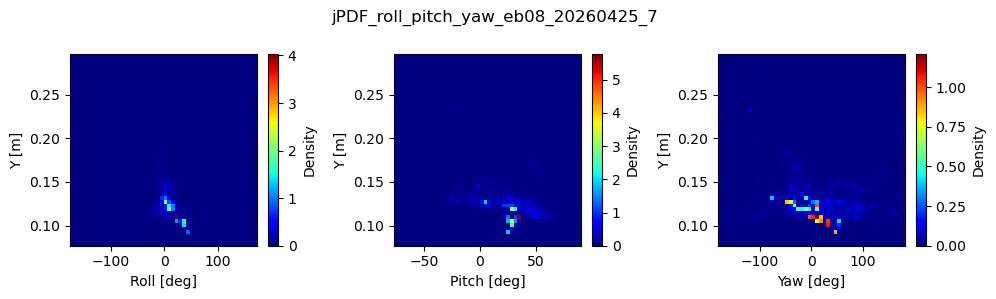

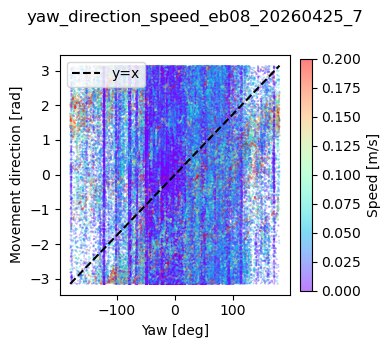

In [7]:
save_dir = Path(paths["data_processed_motive"]) / "qc"
save_dir.parent.mkdir(parents=True, exist_ok=True)

preprocessing.diagnose_session(out_path, save_dir=save_dir, euler_plots=True)